<strong><span style='font-size:40px;color:red'>Transformer build first go (ZPT)

In [114]:
print("starting imports...")
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
import re
from collections import Counter, defaultdict
import nltk
print("Imports completed.")

device = torch.device('mps' if torch.backends.mps.is_built() else 'cpu')
print(f"Using device: {device}")
device = 'cpu'  # Force CPU usage
d_model = 256
train_fresh = True

starting imports...
Imports completed.
Using device: mps


<strong><span style='font-size:25px;color:red'>char tokeniser

In [115]:
class charTokeniser:
    import numpy as np

    def __init__(self, text:str):

        chars = sorted(set(text))
        self.vobab_size = len(chars)

        self.stoi = {ch:i for i, ch in enumerate(chars)}
        self.itos = {i:ch for i, ch in enumerate(chars)}

    def encode(self, text:str):
        return np.array([self.stoi[ch] for ch in text], dtype=np.int64)
    
    def decode(self, tokens:np.ndarray):
        return ''.join([self.itos[int(i)] for i in tokens])

<strong><span style='font-size:25px;color:red'>char embedding

In [116]:
class tokeEmbedding:
    import numpy as np

    def __init__(self, vocab_size, embedding_dim):
        self.weight = np.random.randn(vocab_size, embedding_dim) * 0.01

    def forward(self, toekn_ids):
        return self.weight[toekn_ids]

<strong><span style='font-size:25px;color:red'>sinusoidal positional encoding

In [117]:
def positionalEncoding(seq_len, d_model):
    import numpy as np

    pe =  np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:,None]
    div_term = np.exp(
        np.arange(0,d_model, 2) * (-np.log(10000.0)/d_model)
    )

    pe[:,0::2] = np.sin(position * div_term)
    pe[:,1::2] = np.cos(position * div_term)

    return pe

<strong><span style='font-size:25px;color:red'>Attention mechanism

In [118]:
import numpy as np

def stable_softmax(x, axis=-1):
    x = x-np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.num_heads = num_heads
        self.head_size = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model)
        
        self.scale = self.head_size ** 0.5

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        
        # Calculate raw scores
        scores = (Q @ K.transpose(-2, -1)) / self.scale
        
        # --- CAUSAL MASK START ---
        # Create a triangular mask (1s above the diagonal, 0s on/below)
        # We move it to the same device as x (MPS/CPU)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        
        # Fill the "future" positions with -infinity so they become 0 after softmax
        scores = scores.masked_fill(mask, float('-inf'))
        # --- CAUSAL MASK END ---
        
        weights = torch.softmax(scores, dim=-1)
        out = weights @ V
        
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.fc_out(out), weights
    



<strong><span style='font-size:25px;color:red'> Feed forwards mechanisms

In [119]:
class FeedForwards(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

<strong><span style='font-size:25px;color:red'> Layered Normalisation

In [120]:
class layerNorm:
    def __init__ (self, d_model, eps=1e-6):
        self.gamma = np.ones(d_model)
        self.beta = np.zeros(d_model)
        self.eps = eps

    def forward(self, x):
        # x : (seq_len, d_model)

        mean = x.mean(axis=-1, keepdims=True)
        std = x.std(axis=-1, keepdims=True)
        x_norm = (x - mean) / (std + self.eps)

        return self.gamma * x_norm + self.beta

<strong><span style='font-size:25px;color:red'> Transformer Bock

In [121]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads): # Add num_heads here
        super().__init__()

        # Now we pass both arguments as required
        self.attn = MultiHeadAttention(d_model, num_heads) 
        self.ff = FeedForwards(d_model, d_ff)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x)
        x = self.ln1(x + attn_out)
        ff_out = self.ff(x)
        x = self.ln2(x + ff_out)
        return x, attn_weights



class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, d_ff, vocab_size, max_seq_len, num_heads=4): # Add num_heads with a default
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        pe = torch.tensor(positionalEncoding(max_seq_len, d_model), dtype=torch.float32)
        self.register_buffer("pos_encoding", pe)

        # Pass num_heads into every block we create
        self.layers = nn.ModuleList(
            [TransformerBlock(d_model, d_ff, num_heads) for _ in range(num_layers)]
        )

        self.output = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, token_ids):
        if token_ids.dim() == 1:
            token_ids = token_ids.unsqueeze(0)
            
        batch_size, seq_len = token_ids.shape 
        x = self.token_embedding(token_ids)
        x = x + self.pos_encoding[:seq_len, :]

        for layer in self.layers:
            x, _ = layer(x)

        return self.output(x)
    
    def forward_with_attention(self, token_ids):
        """
        token_ids: (Batch_Size, Seq_Len)
        Returns:
            logits: (Batch_Size, Seq_Len, Vocab_Size)
            attention_maps: list of attention tensors, one per layer
                            each of shape (Batch_Size, Seq_Len, Seq_Len)
        """
        batch_size, seq_len = token_ids.shape

        x = self.token_embedding(token_ids)
        x = x + self.pos_encoding[:seq_len, :]

        attention_maps = []

        for layer in self.layers:
            x, attn = layer(x)
            attention_maps.append(attn.detach())

        logits = self.output(x)
        return logits, attention_maps    

Ask Model - prompt and response

In [122]:
def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
    model.eval()
    prompt = prompt.lower()
    context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
    print(f"Prompt: {prompt}")
    print("Response: ", end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context_cond = context[:, -BLOCK_SIZE:]
            logits = model(context_cond)
            logits = logits[:, -1, :] / temperature
            
            # --- TOP-K FILTERING ---
            # 1. Find the top K values
            v, _ = torch.topk(logits, top_k)
            # 2. Set any value below the Kth value to negative infinity
            logits[logits < v[:, [-1]]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            char = tokeniser.decode(next_token[0].tolist())
            print(char, end="", flush=True)
            
            context = torch.cat((context, next_token), dim=1)
    print("\n" + "-"*30)

In [123]:
# text = "I want to build a transformer from scratch in numpy. how hard can this be? let's find out!"

# text_lower = text.lower()

# print(len(text_lower))

# tokeniser = charTokeniser(text_lower)
# tokens_np = tokeniser.encode(text_lower)

# print("Tokens:", tokens_np)
# print("Decoded:", tokeniser.decode(tokens_np))

# tokens = torch.tensor(tokens_np, dtype=torch.long)


# block = TransformerBlock(d_model, d_ff=64)

# x = torch.randn(len(tokens), d_model)  # fake embeddings
# x_out, attn_weights = block(x)

# print("Block input shape:", x.shape)
# print("Block output shape:", x_out.shape)
# print("Attention shape:", attn_weights.shape)

# encoder = TransformerEncoder(
#     num_layers=2,
#     d_model=d_model,
#     d_ff=64,
#     vocab_size=tokeniser.vobab_size,
#     max_seq_len=len(tokens)
# )

# logits = encoder(tokens)

# print("Encoder output shape:", logits.shape)

visualiseing whats happening

In [124]:
# from matplotlib import pyplot as plt

# attention_map = encoder.forward_with_attention(tokens)[1]

# for i, attn_weights in enumerate(attention_map):
#     plt.imshow(attn_weights, cmap='viridis')
#     plt.colorbar()
#     plt.title(f'Attention Weights - Layer {i+1}')
#     plt.xlabel('Key Positions')
#     plt.ylabel('Query Positions')
#     plt.show()
# text = "hello transformer"

# for i, emb_char in enumerate(text):
#     print(f"Character: {emb_char} -> Token ID: {tokeniser.stoi[emb_char]}") 
#     token_id = tokeniser.stoi[emb_char]
#     emb_vector = embed.forward(np.array([token_id]))
#     print(f"Embedding Vector: {emb_vector}")
#     print()

#     plt.imshow(emb_vector, aspect='auto', cmap='viridis')
#     plt.colorbar()
#     plt.title(f'Embedding Vector for Character: {emb_char}')
#     plt.xlabel('Embedding Dimension')
#     plt.ylabel('Token Index')
#     plt.show()


<strong><span style='color:red;font-size:26px'>base training corpus

In [125]:
# Corpus1 = """hello world
#     hello transformer
#     hello attention
#     hello feedforward
#     hello world
#     hello transformer
#     hello attention
#     hello feedforward

#     attention learns patterns
#     attention learns patterns
#     attention learns patterns

#     transformers stack layers
#     transformers stack layers
#     transformers stack layers

#     the model predicts the next character
#     the model predicts the next character
#     the model predicts the next character"""

itterative weights triaing on corpus1

In [126]:
# import torch
# print(torch.__version__)
# import torch.nn as nn
# import torch.optim as optim

# all_text = text + Corpus1
# tokeniser = charTokeniser(all_text) 

BLOCK_SIZE = 64  # How many characters the model looks at once
# BATCH_SIZE = 16  # How many chunks to process in parallel

# model = TransformerEncoder(
#     num_layers=5,
#     d_model=d_model,
#     d_ff=64,
#     vocab_size=tokeniser.vobab_size,
#     max_seq_len=BLOCK_SIZE,
#     num_heads=4
# )

# model = model.to(device)

# # print(f"New vocab size: {tokeniser.vobab_size}")
# # print(f"All text length: {len(all_text)}")


# def get_batch(data, block_size, batch_size):
#     """
#     Grabs random chunks from the data. 
#     Returns x (inputs) and y (targets)
#     """
#     # Generate random starting indices in the text
#     ix = torch.randint(len(data) - block_size, (batch_size,))
    
#     # Stack the chunks into a matrix
#     x = torch.stack([data[i : i + block_size] for i in ix])
#     y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    
#     return x, y

# def train_step(x, y): # Ensure there are TWO arguments here
#     model.train()
#     optimizer.zero_grad()
#     logits = model(x) 
#     loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
#     loss.backward()
#     optimizer.step()
#     return loss.item()

# criterion = nn.CrossEntropyLoss()

# # FIX IS HERE: removed the [] brackets
# optimizer = optim.SGD(params=model.parameters(), lr=0.05)

# # all_data = torch.tensor(tokeniser.encode(Corpus1), dtype=torch.long)

# # loss_history = []

# # num_epochs = 50
# # for epoch in range(num_epochs):

# #     xb, yb = get_batch(all_data, BLOCK_SIZE, BATCH_SIZE)

# #     xb, yb = xb.to(device), yb.to(device)

# #     loss = train_step(xb, yb)
# #     loss_history.append(loss) # Record the loss

# #     if (epoch+1) % 10 == 0:
# #         print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")
# # model.eval()
# # start_prompt = "hello"
# # input_ids = torch.tensor([tokeniser.stoi[ch] for ch in start_prompt], dtype=torch.long)
# # generated = input_ids.tolist()
# # max_gen_len = 50

# # # Plot the results
# # plt.figure(figsize=(10, 5))
# # plt.plot(loss_history)
# # plt.title("Training Loss Over Time")
# # plt.xlabel("Iteration")
# # plt.ylabel("Cross Entropy Loss")
# # plt.grid(True)
# # plt.show()

# # model.eval()
# # xb, _ = get_batch(all_data, BLOCK_SIZE, batch_size=1)
# # xb = xb.to(device)

# # with torch.no_grad():
# #     logits, attention_maps = model.forward_with_attention(xb)

# # attn = attention_maps[-1][0]  # last layer, first batch element

# # plt.figure(figsize=(8, 6))
# # plt.imshow(attn.cpu(), cmap="viridis")
# # plt.colorbar()
# # plt.title("Final Layer Attention")
# # plt.xlabel("Key (past positions)")
# # plt.ylabel("Query (current position)")
# # plt.show()


In [127]:
# corpus2 = """
# the sun rises in the east
# the sun sets in the west

# water flows downhill
# heat flows from hot to cold

# if it rains the ground gets wet
# if the ground is wet the shoes get dirty

# a cat is an animal
# a dog is an animal
# a bird is an animal

# cats have tails
# dogs have tails
# birds have wings

# a red ball is round
# a blue box is square

# counting starts at zero
# zero comes before one
# one comes before two
# two comes before three

# when a thing moves it changes position
# when position changes time passes

# questions ask for answers
# answers reduce uncertainty

# learning happens in steps
# small steps add up

# the model reads characters
# characters form words
# words form patterns
# patterns form meaning
# """

In [128]:
# def get_batch(data, block_size, batch_size):
#     ix = torch.randint(len(data) - block_size, (batch_size,))
#     x = torch.stack([data[i:i+block_size] for i in ix])
#     y = torch.stack([data[i+1:i+block_size+1] for i in ix])
#     return x, y

# def corpus_mix_ratio(step, total_steps, start=0.8, end=0.2):
#     """
#     Linearly anneals probability of sampling Corpus A
#     # """
#     alpha = step / total_steps
#     return start * (1 - alpha) + end * alpha

# import random



In [129]:
# all_corpora = all_text + corpus2
# tokeniser = charTokeniser(all_corpora)

# data_1 = torch.tensor(tokeniser.encode(all_text), dtype=torch.long)
# data_2 = torch.tensor(tokeniser.encode(corpus2), dtype=torch.long)

# print(f" using device: {device}")

# vocab_size = tokeniser.vobab_size

# nn.Embedding(vocab_size, d_model)

# def get_mixed_batch(step, total_steps):
#     p_A = corpus_mix_ratio(step, total_steps)

#     if random.random() < p_A:
#         return get_batch(data_1, BLOCK_SIZE, BATCH_SIZE)
#     else:
#         return get_batch(data_2, BLOCK_SIZE, BATCH_SIZE)

# num_steps = 5000


# loss_history = []
# optimizer.zero_grad()
# for step in range(num_steps):
#     xb, yb = get_mixed_batch(step, num_steps)

#     xb, yb = xb.to(device), yb.to(device)

#     logits = model(xb)
    
#     # B = Batch (number of sequences)
#     # T = Time (length of sequence / BLOCK_SIZE)
#     # C = Channels (Vocabulary size)
#     B,T,C = logits.shape
#     loss = F.cross_entropy(
#         logits.view(B*T, C),
#         yb.view(B*T)
#     )

#     loss.backward()
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#     optimizer.step()
#     optimizer.zero_grad(set_to_none=True)

#     loss_history.append(loss.item())

#     if (step + 1) % 100 == 0:
#         pA = corpus_mix_ratio(step, num_steps)
#         print(f"Step {step+1}, Loss {loss:.4f}, CorpusA {pA:.2f}, CorpusB {1-pA:.2f}")

# model.eval()
# start_prompt = "the model"

# # Plot the results
# plt.figure(figsize=(10, 5))
# plt.plot(loss_history)
# plt.title("Training Loss Over Time")
# plt.xlabel("Iteration")
# plt.ylabel("Cross Entropy Loss")
# plt.grid(True)
# plt.show()

# encoded_data = torch.tensor(tokeniser.encode(all_corpora), dtype=torch.long)

# model.eval()

# # 2. Get a single batch (batch_size=1) for visualization
# # We use encoded_data instead of all_corpora
# xb, _ = get_batch(encoded_data, BLOCK_SIZE, batch_size=1)
# xb = xb.to(device)

# with torch.no_grad():
#     # Ensure your model returns attention_maps here
#     logits, attention_maps = model.forward_with_attention(xb)

# # 3. Process the attention weights
# # shape: (Num_Heads, Seq_Len, Seq_Len)
# all_heads_attn = attention_maps[-1][0].cpu().detach()
# num_heads = all_heads_attn.shape[0]

# # 4. Setup the grid for individual "views"
# fig, axes = plt.subplots(1, num_heads, figsize=(20, 5))

# # If there's only 1 head, 'axes' isn't a list, so we force it into one
# if num_heads == 1:
#     axes = [axes]

# for i in range(num_heads):
#     # Select the 2D slice for this specific head
#     head_attn = all_heads_attn[i]
    
#     # Plot the heatmap
#     im = axes[i].imshow(head_attn, cmap="viridis")
#     axes[i].set_title(f"Head {i}")
#     axes[i].set_xlabel("Input Tokens")
#     axes[i].set_ylabel("Output Tokens")
    
#     # We add the Causal Mask (Triangular) look now, so you should see
#     # the top-right corner is empty!

# # Add one shared colorbar and a title
# fig.colorbar(im, ax=axes, shrink=0.6)
# plt.suptitle("Individual Attention Head Perspectives (Causal Masked)", fontsize=16)
# plt.tight_layout()
# plt.show()

In [130]:
# import nltk

nltk.download('gutenberg')

# from nltk.corpus import gutenberg
# learning_rate = 3e-4

# book_train_1 = False

# selected_books = [
#         'austen-emma.txt',
#         'austen-persuasion.txt',
#         'austen-sense.txt',
#         'bible-kjv.txt',
#         'blake-poems.txt',
#         'bryant-stories.txt',
#         'burgess-busterbrown.txt',
#         'carroll-alice.txt',
#         'chesterton-ball.txt',
#         'chesterton-brown.txt',
#         'shakespeare-caesar.txt',
#         'shakespeare-hamlet.txt']

# def build_library():
#     full_text = ""
#     for book in selected_books:
#         print(f"Loading {book}...")
#         full_text += gutenberg.raw(book) + "\n\n"
#         print(f"Book {book} loaded. Total length so far: {len(full_text)} characters.")
#     print("All selected books loaded.")
#     return full_text

# def generate_sample(model, prompt="The ", length=100):
#     model.eval()
#     # Encode prompt
#     context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
# # 1. Build the library (this uses .lower() as you defined)
# all_text_library = build_library() 
# # 2. Re-initialize tokenizer on the lowercase text
# tokeniser = charTokeniser(all_text_library)
# # 3. Create the missing 'encoded_books' variable
# # This converts your massive string into the tensor the model actually trains on
# encoded_books = torch.tensor(tokeniser.encode(all_text_library), dtype=torch.long)

# if book_train_1 == True:
#     # 4. Re-initialize the model to match the new vocab size
#     model = TransformerEncoder(
#         num_layers=10,
#         d_model=d_model,
#         d_ff=64,
#         vocab_size=tokeniser.vobab_size, 
#         max_seq_len=BLOCK_SIZE,
#         num_heads=4
#     ).to(device)

#     # 5. Define the optimizer (don't forget this if you re-initialized the model!)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

#     # Now check again
#     print(f"Tokenizer size: {tokeniser.vobab_size}")
#     print(f"Does it know 'T'? {'T' in tokeniser.stoi}")


#     num_steps = 50000
#     eval_interval = 1000
#     save_interval = 2500
#     patience = 20
#     best_val_loss = float('inf')
#     bad_epochs = 0

#     loss_history = []

#     for step in range(num_steps):
#         model.train()

#         xb, yb = get_batch(encoded_books, BLOCK_SIZE, BATCH_SIZE)
#         xb, yb = xb.to(device), yb.to(device)

#         # forward & backwards analysis
#         logits = model(xb)
#         B,T,C = logits.shape
#         loss = F.cross_entropy(
#             logits.view(B*T, C),
#             yb.view(B*T)
#         )
#         loss.backward()

#         # Gradient Clipping
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()
#         optimizer.zero_grad(set_to_none=True)

#         loss_history.append(loss.item())

#         # Evaluation, Early Stopping and checkpointing
#         if (step + 1) % eval_interval == 0:
#                 model.eval()
                
#                 # 1. Stable Validation Loss (Average over 10 batches)
#                 cumulative_val_loss = 0
#                 num_val_batches = 10
#                 with torch.no_grad():

#                     length = 100

#                     for _ in range(num_val_batches):
#                         xb_v, yb_v = get_batch(encoded_books, BLOCK_SIZE, BATCH_SIZE)
#                         xb_v, yb_v = xb_v.to(device), yb_v.to(device)
#                         v_logits = model(xb_v)
#                         B, T, C = v_logits.shape
#                         cumulative_val_loss += F.cross_entropy(v_logits.view(B*T, C), yb_v.view(B*T)).item()
                
#                 val_loss = cumulative_val_loss / num_val_batches

#                 # 2. Generation Sample (Fixing the 'context' error)
#                 with torch.no_grad():
#                     # Initialize context here so it exists for the generator
#                     context = torch.tensor(tokeniser.encode("The "), dtype=torch.long, device=device).unsqueeze(0)
#                     for _ in range(length):
#                         context_cond = context[:, -BLOCK_SIZE:]
#                         logits = model(context_cond)
#                         probs = F.softmax(logits[:, -1, :], dim=-1)
#                         next_token = torch.multinomial(probs, num_samples=1)
#                         context = torch.cat((context, next_token), dim=1)
                    
#                     print(f"\n--- STEP {step+1} SAMPLE ---\n{tokeniser.decode(context[0].tolist())}\n")

#                 print(f"Step {step+1}, Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}")

#                 # 3. Early Stopping (Now uses the stable average loss)
#                 if val_loss < best_val_loss:
#                     best_val_loss = val_loss
#                     bad_epochs = 0
#                     torch.save(model.state_dict(), "best_model.pth") # Save the winner!
#                     print(f"New best model saved with val loss: {best_val_loss:.4f}")
#                 else:
#                     bad_epochs += 1
#                     if bad_epochs >= patience:
#                         print(f"Stopping: Val loss hasn't improved in {patience} evals.")
#                         break
                
#                 model.train() # Switch back to training mode!
#     import matplotlib.pyplot as plt
#     import numpy as np

#     def visualize_training_results(loss_history, model, encoded_books, tokeniser):
#         # --- Part 1: Loss History ---
#         plt.figure(figsize=(12, 5))
#         plt.plot(loss_history, label='Training Loss', alpha=0.3, color='blue')
#         # Calculate a moving average to see the trend through the noise
#         if len(loss_history) > 100:
#             ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
#             plt.plot(ma, label='Moving Average (100 steps)', color='red', linewidth=2)
#         plt.title("Training Loss Over Time")
#         plt.xlabel("Step")
#         plt.ylabel("Cross Entropy Loss")
#         plt.legend()
#         plt.grid(True, alpha=0.3)
#         plt.show()

#         # --- Part 2: Attention Head Visualization ---
#         model.eval()
#         # Grab a fresh batch to see attention in action
#         xb, _ = get_batch(encoded_books, BLOCK_SIZE, batch_size=1)
#         xb = xb.to(device)
        
#         with torch.no_grad():
#             # Ensure your model has a method 'forward_with_attention' 
#             # that returns (logits, attention_maps)
#             _, attention_maps = model.forward_with_attention(xb)
        
#         # Let's look at the LAST layer (usually the most semantic)
#         # attention_maps[-1] shape: (Batch, Heads, Time, Time)
#         last_layer_attn = attention_maps[-1][0].cpu() 
#         num_heads = last_layer_attn.shape[0]
        
#         fig, axes = plt.subplots(2, (num_heads + 1) // 2, figsize=(20, 10))
#         axes = axes.flatten()
        
#         for i in range(num_heads):
#             ax = axes[i]
#             im = ax.imshow(last_layer_attn[i], cmap='viridis')
#             ax.set_title(f"Head {i}")
#             ax.axis('off')
        
#         plt.suptitle(f"Final Layer Attention Heads (Step {len(loss_history)})", fontsize=16)
#         fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
#         plt.show()

#     # Call this after your training loop finishes
#     visualize_training_results(loss_history, model, encoded_books, tokeniser)

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [131]:
# print(gutenberg.fileids())

# book_round_2 = ['austen-emma.txt', 
#                 'austen-persuasion.txt', 
#                 'austen-sense.txt', 
#                 'bible-kjv.txt', 
#                 'blake-poems.txt', 
#                 'bryant-stories.txt', 
#                 'burgess-busterbrown.txt', 
#                 'carroll-alice.txt', 
#                 'chesterton-ball.txt', 
#                 'chesterton-brown.txt', 
#                 'chesterton-thursday.txt', 
#                 'edgeworth-parents.txt', 
#                 'melville-moby_dick.txt', 
#                 'milton-paradise.txt', 
#                 'shakespeare-caesar.txt', 
#                 'shakespeare-hamlet.txt', 
#                 'shakespeare-macbeth.txt', 
#                 'whitman-leaves.txt']

# book_round_2 = list(set(book_round_2) - set(selected_books))

# def build_library():
#     new_text = ""

#     for book in book_round_2:
#         print(f"Loading {book}...")
#         new_text += gutenberg.raw(book) + "\n\n"

#         print(f"Book {book} loaded. Total length so far: {len(new_text)} characters.")

#     print("All selected books loaded.")
#     return new_text

# def clean_text(text, allowed_chars):
#     return ''.join(ch for ch in text if ch in allowed_chars)

# def get_mixed_batch(step, total_steps):
#     if torch.rand(1).item() < corpus_mix_ratio(step, total_steps):
#         return get_batch(encoded_new, BLOCK_SIZE, BATCH_SIZE)
#     else:
#         return get_batch(encoded_books, BLOCK_SIZE, BATCH_SIZE)

# def eval_loss(data):
#     total = 0
#     for _ in range(10):
#         xb, yb = get_batch(data, BLOCK_SIZE, BATCH_SIZE)
#         xb, yb = xb.to(device), yb.to(device)
#         logits = model(xb)
#         B,T,C = logits.shape
#         total += F.cross_entropy(
#             logits.view(B*T, C),
#             yb.view(B*T)
#         ).item()
#     return total / 10

# allowed = set(tokeniser.stoi.keys())
# new_text = build_library()
# cleaned_new_text = clean_text(new_text, allowed)
# encoded_new = torch.tensor(tokeniser.encode(cleaned_new_text), dtype=torch.long)

# model = TransformerEncoder(
#     num_layers=10,
#     d_model=d_model,
#     d_ff=64,
#     vocab_size=tokeniser.vobab_size,
#     max_seq_len=BLOCK_SIZE,
#     num_heads=4
# ).to(device)

# state = torch.load("best_model.pth")

# for k in list(state.keys()):
#     if "token_embedding" in k or "output" in k:
#         del state[k]

# model.load_state_dict(state, strict=False)

# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=1e-4
# )

# torch.save({
#     "model": model.state_dict(),
#     "tokenizer": tokeniser.stoi,
#     "step": step,
# }, "zpt_round2_best.pth")

# num_steps = 100000
# eval_interval = 1000
# save_interval = 2500
# patience = 20
# best_val_loss = float('inf')
# bad_epochs = 0

# loss_history = []

# for step in range(num_steps):
#     model.train()

#     xb, yb = get_mixed_batch(step, num_steps)
#     xb, yb = xb.to(device), yb.to(device)

#     # forward & backwards analysis
#     logits = model(xb)
#     B,T,C = logits.shape
#     loss = F.cross_entropy(
#         logits.view(B*T, C),
#         yb.view(B*T)
#     )
#     loss.backward()

#     # Gradient Clipping
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#     optimizer.step()
#     optimizer.zero_grad(set_to_none=True)

#     loss_history.append(loss.item())

#     # Evaluation, Early Stopping and checkpointing
#     if (step + 1) % eval_interval == 0:
#         model.eval()

#         def eval_loss(data):
#             cumulative = 0.0
#             for _ in range(10):
#                 xb_v, yb_v = get_batch(data, BLOCK_SIZE, BATCH_SIZE)
#                 xb_v, yb_v = xb_v.to(device), yb_v.to(device)

#                 v_logits = model(xb_v)
#                 B, T, C = v_logits.shape

#                 cumulative += F.cross_entropy(
#                     v_logits.view(B*T, C),
#                     yb_v.view(B*T)
#                 ).item()

#             return cumulative / 10

#         with torch.no_grad():
#             # Evaluate both corpora
#             val_loss_old = eval_loss(encoded_books)   # Round 1 knowledge
#             val_loss_new = eval_loss(encoded_new)     # New books

#             # Blend them (can be tuned later)
#             val_loss = 0.5 * val_loss_old + 0.5 * val_loss_new

#             # Optional: text sample (set length > 0 if you want output)
#             length = 0
#             if length > 0:
#                 context = torch.tensor(
#                     tokeniser.encode("The "),
#                     dtype=torch.long,
#                     device=device
#                 ).unsqueeze(0)

#                 for _ in range(length):
#                     context_cond = context[:, -BLOCK_SIZE:]
#                     logits = model(context_cond)
#                     probs = F.softmax(logits[:, -1, :], dim=-1)
#                     next_token = torch.multinomial(probs, num_samples=1)
#                     context = torch.cat((context, next_token), dim=1)

#                 print(f"\n--- STEP {step+1} SAMPLE ---")
#                 print(tokeniser.decode(context[0].tolist()))

#         print(
#             f"Step {step+1} | "
#             f"Train {loss:.4f} | "
#             f"Val(old) {val_loss_old:.4f} | "
#             f"Val(new) {val_loss_new:.4f}"
#         )

#         # Early stopping + checkpointing
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             bad_epochs = 0
#             torch.save(model.state_dict(), "best_model_book_extension_1.pth")
#             print(f"New best model saved (combined val loss {best_val_loss:.4f})")
#         else:
#             bad_epochs += 1
#             if bad_epochs >= patience:
#                 print(f"Stopping: validation hasn’t improved in {patience} evals.")
#                 break

#         model.train()

In [132]:
# def visualize_training_results(
#     loss_history,
#     model,
#     encoded_old,
#     encoded_new,
#     tokeniser,
#     focus="new"   # "old" or "new"
# ):
#     # --- Part 1: Loss History ---
#     plt.figure(figsize=(12, 5))
#     plt.plot(loss_history, label="Training Loss", alpha=0.3)

#     if len(loss_history) > 100:
#         ma = np.convolve(loss_history, np.ones(100) / 100, mode="valid")
#         plt.plot(ma, label="Moving Avg (100)", linewidth=2)

#     plt.title("Training Loss Over Time")
#     plt.xlabel("Step")
#     plt.ylabel("Cross Entropy Loss")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # --- Part 2: Attention Visualization ---
#     model.eval()

#     # Choose which corpus to inspect
#     if focus == "old":
#         data = encoded_old
#         title_suffix = "Old Corpus"
#     else:
#         data = encoded_new
#         title_suffix = "New Corpus"

#     xb, _ = get_batch(data, BLOCK_SIZE, batch_size=1)
#     xb = xb.to(device)

#     with torch.no_grad():
#         _, attention_maps = model.forward_with_attention(xb)

#     # Last layer attention (Batch, Heads, T, T)
#     last_layer_attn = attention_maps[-1][0].cpu()
#     num_heads = last_layer_attn.shape[0]

#     fig, axes = plt.subplots(
#         2,
#         (num_heads + 1) // 2,
#         figsize=(20, 10)
#     )
#     axes = axes.flatten()

#     for i in range(num_heads):
#         ax = axes[i]
#         im = ax.imshow(last_layer_attn[i], cmap="viridis")
#         ax.set_title(f"Head {i}")
#         ax.axis("off")

#     plt.suptitle(
#         f"Final Layer Attention Heads – {title_suffix}",
#         fontsize=16
#     )
#     fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
#     plt.show()


# visualize_training_results(
#     loss_history,
#     model,
#     encoded_books,   # old corpus
#     encoded_new,     # new corpus
#     tokeniser,
#     focus="new"      # or "old"
# )

# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="old")
# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="new")

coherenece testing

In [133]:
# def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
#     model.eval()
#     prompt = prompt.lower()
#     context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
#     print(f"Prompt: {prompt}")
#     print("Response: ", end="")
    
#     with torch.no_grad():
#         for _ in range(max_new_tokens):
#             context_cond = context[:, -BLOCK_SIZE:]
#             logits = model(context_cond)
#             logits = logits[:, -1, :] / temperature
            
#             # --- TOP-K FILTERING ---
#             # 1. Find the top K values
#             v, _ = torch.topk(logits, top_k)
#             # 2. Set any value below the Kth value to negative infinity
#             logits[logits < v[:, [-1]]] = -float('Inf')
            
#             probs = F.softmax(logits, dim=-1)
#             next_token = torch.multinomial(probs, num_samples=1)
            
#             char = tokeniser.decode(next_token[0].tolist())
#             print(char, end="", flush=True)
            
#             context = torch.cat((context, next_token), dim=1)
#     print("\n" + "-"*30)

# # --- HOW TO USE IT ---
# ask_model(model, tokeniser, "how art thou", max_new_tokens=150, temperature=0.4)

In [134]:
# from nltk.corpus import brown, reuters, webtext

# encoded_new = torch.cat([encoded_new, encoded_books])

# model.load_state_dict(torch.load("best_model_book_extension_1.pth"))
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

# nltk.download('brown')
# nltk.download('reuters')
# nltk.download('webtext')

# def get_modern_corpus():
#     modern_text = ""
#     corpora = [brown, reuters, webtext]
    
#     for corpus in corpora:
#         for fileid in corpus.fileids():
#             modern_text += corpus.raw(fileid) + "\n\n"
    
#     return modern_text

# modern_corpus = get_modern_corpus()

# cleaned_modern_text = clean_text(modern_corpus, allowed)

# encoded_modern = torch.tensor(tokeniser.encode(cleaned_modern_text), dtype=torch.long)

# tokeniser = charTokeniser(all_corpora + modern_corpus)


# def get_mixed_batch(step, total_steps, modern_weight=0.7):
#     # modern_weight=0.7 means 70% Modern, 30% Old
#     if torch.rand(1).item() < modern_weight:
#         # Train on Modern
#         return get_batch(encoded_modern, BLOCK_SIZE, BATCH_SIZE)
#     else:
#         # Train on Old (Gutenberg/Bible)
#         return get_batch(encoded_new, BLOCK_SIZE, BATCH_SIZE)

# model.load_state_dict(torch.load("best_model_book_extension_1.pth"))

# torch.save({
#     "model": model.state_dict(),
#     "tokenizer": tokeniser.stoi,
#     "step": step,
# }, "best_model_book_extension_2.pth")

# num_steps = 100000

# for step in range(num_steps):
#     model.train()

#     # Using your mixed batch logic
#     xb, yb = get_mixed_batch(step, num_steps, modern_weight=0.7)
#     xb, yb = xb.to(device), yb.to(device)

#     logits = model(xb)
#     B, T, C = logits.shape
#     loss = F.cross_entropy(logits.view(B*T, C), yb.view(B*T))
    
#     optimizer.zero_grad(set_to_none=True)
#     loss.backward()
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#     optimizer.step()

#     # --- 4. EVALUATION ---
#     if (step + 1) % eval_interval == 0:
#         model.eval()
        
#         with torch.no_grad():
#             # Evaluate all three to get a true sense of the model
#             val_new = eval_loss(encoded_new)
#             val_mod = eval_loss(encoded_modern) # IMPORTANT: Check the modern data too!

#             # Weighted validation loss
#             val_loss = (0.2 * val_new) + (0.6 * val_mod)

#         print(f"Step {step+1} | Train {loss:.4f} | Val(Mod) {val_mod:.4f}")

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             bad_epochs = 0
#             # Save the full checkpoint
#             torch.save({
#                 "model": model.state_dict(),
#                 "optimizer": optimizer.state_dict(),
#                 "step": step,
#                 "loss": val_loss
#             }, "zpt_round3_best.pth")
#             print("--- New Best Model Saved ---")
#         else:
#             bad_epochs += 1
#             if bad_epochs >= patience:
#                 print(f"Early stopping at step {step+1}")
#                 break
        
#         model.train()

In [135]:
# def visualize_training_results(
#     loss_history,
#     model,
#     encoded_modern,
#     encoded_new,
#     tokeniser,
#     focus="new"   # "old" or "new"
# ):
#     # --- Part 1: Loss History ---
#     plt.figure(figsize=(12, 5))
#     plt.plot(loss_history, label="Training Loss", alpha=0.3)

#     if len(loss_history) > 100:
#         ma = np.convolve(loss_history, np.ones(100) / 100, mode="valid")
#         plt.plot(ma, label="Moving Avg (100)", linewidth=2)

#     plt.title("Training Loss Over Time")
#     plt.xlabel("Step")
#     plt.ylabel("Cross Entropy Loss")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # --- Part 2: Attention Visualization ---
#     model.eval()

#     # Choose which corpus to inspect
#     if focus == "old":
#         data = encoded_new
#         title_suffix = "Old Corpus"
#     else:
#         data = encoded_modern
#         title_suffix = "New Corpus"

#     xb, _ = get_batch(data, BLOCK_SIZE, batch_size=1)
#     xb = xb.to(device)

#     with torch.no_grad():
#         _, attention_maps = model.forward_with_attention(xb)

#     # Last layer attention (Batch, Heads, T, T)
#     last_layer_attn = attention_maps[-1][0].cpu()
#     num_heads = last_layer_attn.shape[0]

#     fig, axes = plt.subplots(
#         2,
#         (num_heads + 1) // 2,
#         figsize=(20, 10)
#     )
#     axes = axes.flatten()

#     for i in range(num_heads):
#         ax = axes[i]
#         im = ax.imshow(last_layer_attn[i], cmap="viridis")
#         ax.set_title(f"Head {i}")
#         ax.axis("off")

#     plt.suptitle(
#         f"Final Layer Attention Heads – {title_suffix}",
#         fontsize=16
#     )
#     fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
#     plt.show()


# visualize_training_results(
#     loss_history,
#     model,
#     encoded_books,   # old corpus
#     encoded_new,     # new corpus
#     tokeniser,
#     focus="new"      # or "old"
# )

# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="old")
# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="new")

In [136]:
def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
    model.eval()
    prompt = prompt.lower()
    context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
    print(f"Prompt: {prompt}")
    print("Response: ", end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context_cond = context[:, -BLOCK_SIZE:]
            logits = model(context_cond)
            logits = logits[:, -1, :] / temperature
            
            # --- TOP-K FILTERING ---
            # 1. Find the top K values
            v, _ = torch.topk(logits, top_k)
            # 2. Set any value below the Kth value to negative infinity
            logits[logits < v[:, [-1]]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            char = tokeniser.decode(next_token[0].tolist())
            print(char, end="", flush=True)
            
            context = torch.cat((context, next_token), dim=1)
    print("\n" + "-"*30)

# model.load_state_dict(torch.load("zpt_round3_best.pth")["model"])

# # --- HOW TO USE IT ---
# ask_model(model, tokeniser, "the economy is growing because", max_new_tokens=1500, temperature=0.8)

In [137]:
def get_stats(tokens):
    pairs = Counter()
    for word in tokens:
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += 1
    return pairs

def merge_vocab(pair, vocab):
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    new_vocab = {}
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

def train_bpe(corpus, vocab_size=5000):
    # Pre-tokenize roughly by whitespace to build the word dictionary
    # We add </w> to mark end of words so "the" and "the " are distinct
    print("Building initial word dictionary...")
    vocab = Counter()
    for word in corpus.split():
        # Space-separated chars: "m a r k e t </w>"
        vocab[" ".join(list(word)) + " </w>"] += 1

    # Get the set of all initial characters (base vocab)
    # We need this to ensure single letters are known even if never merged
    base_vocab = set()
    for word in vocab.keys():
        base_vocab.update(word.split())
    
    print(f"Initial base characters: {len(base_vocab)}")
    
    # Calculate how many merges we can afford
    # Target size - existing base chars = remaining slots for merges
    num_merges = vocab_size - len(base_vocab)
    print(f"Training BPE for {num_merges} merges...")

    merges = []
    for i in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
            
        best = max(pairs, key=pairs.get)
        vocab = merge_vocab(best, vocab)
        merges.append(best)
        
        if (i+1) % 100 == 0:
            print(f"Merge {i+1}/{num_merges}: {best}")

    return merges, base_vocab

In [138]:
import re

class BPETokeniser:
    def __init__(self, merges, base_vocab):
        self.merges = merges
        
        # rank: lower = higher priority
        self.merge_ranks = {merge: i for i, merge in enumerate(merges)}
        
        self.vocab = self._build_vocab(base_vocab)
        self.decoder = {v: k for k, v in self.vocab.items()}

    def _build_vocab(self, base_vocab):
        vocab = {k: i for i, k in enumerate(sorted(list(base_vocab)))}

        if "<unk>" not in vocab:
            vocab["<unk>"] = len(vocab)

        current_id = len(vocab)

        for (p0, p1) in self.merges:
            token = p0 + p1
            if token not in vocab:
                vocab[token] = current_id
                current_id += 1

        return vocab

    # ------------------------------
    # REAL BPE MERGE IMPLEMENTATION
    # ------------------------------
    def _get_pairs(self, tokens):
        # returns set of adjacent symbol pairs
        return {(tokens[i], tokens[i+1]) for i in range(len(tokens) - 1)}

    def bpe_word(self, word):
        # turn word into list of symbols
        tokens = list(word) + ["</w>"]

        if len(tokens) == 1:
            return tokens

        pairs = self._get_pairs(tokens)

        while True:
            candidate = None
            best_rank = None

            # find highest priority valid pair
            for pair in pairs:
                if pair in self.merge_ranks:
                    rank = self.merge_ranks[pair]
                    if best_rank is None or rank < best_rank:
                        best_rank = rank
                        candidate = pair

            # no more mergeable pairs
            if candidate is None:
                break

            p0, p1 = candidate
            new_tokens = []
            i = 0

            # merge every occurrence of best pair
            while i < len(tokens):
                if (
                    i < len(tokens) - 1 
                    and tokens[i] == p0 
                    and tokens[i+1] == p1
                ):
                    new_tokens.append(p0 + p1)
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1

            tokens = new_tokens
            if len(tokens) == 1:
                break
            pairs = self._get_pairs(tokens)

        return tokens

    # ------------------------------
    # PUBLIC API
    # ------------------------------
    def encode(self, text):
        words = text.split()
        ids = []

        for word in words:
            symbols = self.bpe_word(word)
            for s in symbols:
                ids.append(self.vocab.get(s, self.vocab["<unk>"]))

        return ids

    def decode(self, ids):
        text = "".join([self.decoder.get(idx, "") for idx in ids])
        return text.replace("</w>", " ")

In [139]:
def get_batch(text, block_size, batch_size):
    tokens = torch.tensor(BPETokeniser.encode(text), dtype=torch.long)
    ix = torch.randint(len(tokens) - block_size, (batch_size,))
    x = torch.stack([tokens[i:i+block_size] for i in ix])
    y = torch.stack([tokens[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [140]:
nltk.download('gutenberg')

books = ['austen-emma.txt', 
                'austen-persuasion.txt', 
                'austen-sense.txt', 
                'bible-kjv.txt', 
                'blake-poems.txt', 
                'bryant-stories.txt', 
                'burgess-busterbrown.txt', 
                'carroll-alice.txt', 
                'chesterton-ball.txt', 
                'chesterton-brown.txt', 
                'chesterton-thursday.txt', 
                'edgeworth-parents.txt', 
                'melville-moby_dick.txt', 
                'milton-paradise.txt', 
                'shakespeare-caesar.txt', 
                'shakespeare-hamlet.txt', 
                'shakespeare-macbeth.txt', 
                'whitman-leaves.txt']

def build_library_full():
    new_text = ""

    for book in books:
        print(f"Loading {book}...")
        new_text += gutenberg.raw(book) + "\n\n"

        print(f"Book {book} loaded. Total length so far: {len(new_text)} characters.")

    print("All selected books loaded.")
    return new_text

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [ ]:
nltk.download('brown')
nltk.download('reuters')
nltk.download('webtext')

from nltk.corpus import brown, reuters, webtext

def get_modern_corpus():
    modern_text = ""
    corpora = [brown, reuters, webtext]
    
    for corpus in corpora:
        for fileid in corpus.fileids():
            modern_text += corpus.raw(fileid) + "\n\n"
    
    return modern_text

modern_corpus = get_modern_corpus()

[nltk_data] Downloading package brown to /Users/zacwells/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package reuters to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package webtext to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package webtext is already up-to-date!


In [142]:
if train_fresh == True:

    all_books = build_library_full()
    modern_corpus = get_modern_corpus()

    all_text = all_books + modern_corpus
    print(f"Total corpus length: {len(all_text)} characters.")

    # 1. Train BPE on all corpora
    merges, base_vocab = train_bpe(all_text, vocab_size=5_000)

    # 2. Build tokenizer from merges
    tokeniser = BPETokeniser(merges, base_vocab)

    # 3. Get vocab size FROM tokenizer (not chars)
    vocab_size = len(tokeniser.vocab)
    print("BPE vocab size:", vocab_size)

    # 4. Create model with correct vocab size
    model = TransformerEncoder(
        num_layers=10,
        d_model=d_model,
        d_ff=64,
        vocab_size=vocab_size,
        max_seq_len=BLOCK_SIZE,¬
        num_heads=4
    ).to(device)

    # test run of BPE tokenizer
    test = "markets are up"
    ids = tokeniser.encode(test)

    print("Encoded:", ids)
    print("Decoded:", tokeniser.decode(ids))

Loading austen-emma.txt...
Book austen-emma.txt loaded. Total length so far: 887073 characters.
Loading austen-persuasion.txt...
Book austen-persuasion.txt loaded. Total length so far: 1353367 characters.
Loading austen-sense.txt...
Book austen-sense.txt loaded. Total length so far: 2026391 characters.
Loading bible-kjv.txt...
Book bible-kjv.txt loaded. Total length so far: 6358947 characters.
Loading blake-poems.txt...
Book blake-poems.txt loaded. Total length so far: 6397102 characters.
Loading bryant-stories.txt...
Book bryant-stories.txt loaded. Total length so far: 6646543 characters.
Loading burgess-busterbrown.txt...
Book burgess-busterbrown.txt loaded. Total length so far: 6731208 characters.
Loading carroll-alice.txt...
Book carroll-alice.txt loaded. Total length so far: 6875605 characters.
Loading chesterton-ball.txt...
Book chesterton-ball.txt loaded. Total length so far: 7333057 characters.
Loading chesterton-brown.txt...
Book chesterton-brown.txt loaded. Total length so fa

In [143]:
# # --- 1. ENCODE DATA ---
# def encode_corpus_by_line(tokeniser, text):
#     token_ids = []
#     lines = text.splitlines()
#     for i, line in enumerate(lines):
#         token_ids.extend(tokeniser.encode(line + "\n"))
#         if i % 1000 == 0:
#             print(f"Encoded {i:,}/{len(lines):,} lines")
#     return token_ids

def encode_corpus_in_chunks(tokeniser, text, chunk_size=200_000):
    token_ids = []
    for i in range(0, len(text), chunk_size):
        chunk = text[i:i + chunk_size]
        token_ids.extend(tokeniser.encode(chunk))
        print(f"Encoded {i + len(chunk):,}/{len(text):,} characters")
    return token_ids

if train_fresh == True:

    print("Encoding full corpus...")
    full_token_ids = encode_corpus_in_chunks(tokeniser, all_text)

    # Convert to a PyTorch tensor
    # dtype=torch.long is required for embedding layers
    data_tensor = torch.tensor(full_token_ids, dtype=torch.long)

    print(f"Total tokens in tensor: {len(data_tensor)}")

    torch.save(full_token_ids, "bpe_tokens.pt")
else:
    print("Loading pre-encoded tokens...")
    full_token_ids = torch.load("bpe_tokens.pt")
    data_tensor = torch.tensor(full_token_ids, dtype=torch.long)
    print(f"Total tokens in tensor: {len(data_tensor)}")

# --- 2. CREATE TRAIN/VAL SPLIT ---
# We'll use 90% for training, 10% for validation
n = int(0.9 * len(data_tensor))

train_data = data_tensor[:n]
val_data = data_tensor[n:]

print(f"Training tokens: {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

Encoding full corpus...
Encoded 200,000/32,353,243 characters
Encoded 400,000/32,353,243 characters
Encoded 600,000/32,353,243 characters
Encoded 800,000/32,353,243 characters
Encoded 1,000,000/32,353,243 characters
Encoded 1,200,000/32,353,243 characters
Encoded 1,400,000/32,353,243 characters
Encoded 1,600,000/32,353,243 characters
Encoded 1,800,000/32,353,243 characters
Encoded 2,000,000/32,353,243 characters
Encoded 2,200,000/32,353,243 characters
Encoded 2,400,000/32,353,243 characters
Encoded 2,600,000/32,353,243 characters
Encoded 2,800,000/32,353,243 characters
Encoded 3,000,000/32,353,243 characters
Encoded 3,200,000/32,353,243 characters
Encoded 3,400,000/32,353,243 characters
Encoded 3,600,000/32,353,243 characters
Encoded 3,800,000/32,353,243 characters
Encoded 4,000,000/32,353,243 characters
Encoded 4,200,000/32,353,243 characters
Encoded 4,400,000/32,353,243 characters
Encoded 4,600,000/32,353,243 characters
Encoded 4,800,000/32,353,243 characters
Encoded 5,000,000/32,353

training loop with assessmenet breaks BPE

In [ ]:
if train_fresh == True:
    # --- B. BATCH FUNCTION ---
    def get_batch(split):
        # Select the correct tensor
        data = train_data if split == 'train' else val_data
        
        # Generate random starting points (indices)
        ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
        
        # Stack the chunks into rows
        x = torch.stack([data[i:i+BLOCK_SIZE] for i in ix])
        y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
        
        # Move to GPU/MPS
        return x.to(device), y.to(device)

    BATCH_SIZE = 512

    # --- A. INITIALIZE FRESH MODEL ---
    # Do not load old weights. BPE requires a fresh brain.
    model = TransformerEncoder(
        num_layers=10,
        d_model=d_model,  # Ensure this is defined (e.g., 256 or 512)
        d_ff=d_model * 4, # Standard practice is 4x the embedding size
        vocab_size=len(tokeniser.vocab), # FIX: Use len(vocab), not .vobab_size
        max_seq_len=BLOCK_SIZE,
        num_heads=4
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # Slightly lower LR for BPE

    # --- C. TRAINING LOOP ---
    num_steps = 400_000
    eval_interval = 1000
    patience = 20
    best_val_loss = float('inf')
    bad_epochs = 0
    loss_history = []

    print("Starting BPE Training...")

    for step in range(num_steps):
        model.train()
        
        # 1. Get batch (now uses the BPE encoded tensors)
        xb, yb = get_batch('train')
        
        # 2. Forward pass
        logits = model(xb)
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B*T, C), yb.view(B*T))
        
        # 3. Backward pass
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        loss_history.append(loss.item())

        # 4. Evaluation
        if (step + 1) % eval_interval == 0:
            model.eval()
            with torch.no_grad():
                # Estimate val loss over 10 batches
                val_losses = [
                    F.cross_entropy(
                        model(get_batch('val')[0]).view(-1, C), 
                        get_batch('val')[1].view(-1)
                    ).item() 
                    for _ in range(10)
                ]
                avg_val = sum(val_losses) / len(val_losses)
                
                # --- Quick Text Sample ---
                # We must encode the prompt first!
                prompt_ids = tokeniser.encode("The market ")
                ctx = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)
                
                # Generate just 10 tokens for a quick check
                for _ in range(10):
                    logits = model(ctx[:, -BLOCK_SIZE:])
                    probs = F.softmax(logits[:, -1, :], dim=-1)
                    next_tok = torch.multinomial(probs, 1)
                    ctx = torch.cat((ctx, next_tok), dim=1)
                    
                decoded = tokeniser.decode(ctx[0].tolist())
                
            print(f"Step {step+1}: Train {loss:.4f} | Val {avg_val:.4f} | Output: '{decoded}...'")

Starting BPE Training...
Step 1000: Train 2.4047 | Val 9.4159 | Output: 'The market marketer. He had eas...'
Step 2000: Train 2.1723 | Val 10.1728 | Output: 'The market is poorne presid...'


In [ ]:
torch.save(
    {
        "model": model.state_dict(),
        "tokenizer": tokeniser.vocab,
        "step": step,
    },
    "best_model_bpe.pth"
)

In [ ]:
if train_fresh == False:
    import torch

    # -----------------------------
    # 1. Load checkpoint
    # -----------------------------
    checkpoint = torch.load("best_model_bpe.pth", map_location="cpu")
    state_dict = checkpoint["model"]

    # -----------------------------
    # 2. Infer params (vocab, d_model, AND max_seq_len)
    # -----------------------------
    vocab_size = None
    d_model = None
    max_seq_len = None

    # We look for specific keys to determine shapes
    for key, tensor in state_dict.items():
        # Detect embedding to find vocab_size and d_model
        # (Assuming standard names like 'embedding.weight', 'encoder.embedding.weight', etc.)
        if "embedding" in key and tensor.ndim == 2 and vocab_size is None:
            vocab_size, d_model = tensor.shape
            print(f"Found embedding '{key}': vocab_size={vocab_size}, d_model={d_model}")
        
        # Detect pos_encoding to find max_seq_len
        # The error message specifically mentioned the key "pos_encoding"
        if "pos_encoding" in key:
            # Check if shape is [max_len, d_model] or [1, max_len, d_model]
            if tensor.ndim == 2:
                max_seq_len = tensor.shape[0]
            elif tensor.ndim == 3:
                # Usually [1, max_len, d_model] or [max_len, 1, d_model]
                # We pick the dimension that matches neither 1 nor d_model (usually)
                # But simpler: usually max_len is the largest dim usually, or the one matching d_model is last.
                # Based on your error, your shape is [64, 256], so it's 2D.
                max_seq_len = max(tensor.shape) 
                
            print(f"Found pos_encoding '{key}': inferred max_seq_len={max_seq_len}")

    # Fallback if detection failed (safety check)
    if vocab_size is None or max_seq_len is None:
        raise RuntimeError("Could not infer model parameters from state_dict. Please check key names.")

    # -----------------------------
    # 3. Recreate model architecture
    # -----------------------------
    # Use the INFERRED max_seq_len, not the hardcoded one
    model = TransformerEncoder(
        vocab_size=vocab_size,
        d_model=d_model,
        num_heads=4,
        num_layers=10,
        d_ff=d_model * 4,
        max_seq_len=max_seq_len, 
    )

    data = checkpoint["tokenizer"]
    print("Keys found:", data.keys())
    tokeniser = checkpoint["tokenizer"]
    tokeniser = BPETokeniser(
        merges=[(k[:-1], k[-1]) for k in sorted(tokeniser.keys()) if len(k) > 1],
        base_vocab={k for k in tokeniser.keys() if len(k) == 1}
    )
    # -----------------------------
    # 4. Load weights
    # -----------------------------
    # strict=True is default, but ensuring keys match exactly is good practice
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    # -----------------------------
    # 5. Restore step (optional)
    # -----------------------------
    step = checkpoint.get("step", 0)
    print(f"Model loaded successfully at step {step} (Seq Len: {max_seq_len})")

Found pos_encoding 'pos_encoding': inferred max_seq_len=64
Found embedding 'token_embedding.weight': vocab_size=5001, d_model=256
Keys found: dict_keys(['\x1a', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '</w>', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '\x91', '\x92', '\x93', '\x94', '\x97', '\x99', '´', 'Â', 'ß', 'â', 'ä', 'æ', 'è', 'é', 'î', 'ö', 'ü', 'Ă', 'č', 'ď', 'ĺ', 'Ł', 'ŕ', 'Ť', 'ť', 'ż', '˝', '<unk>', '/n', 'in', ',</w>', 'er', '/nn', 's</w>', 'on', 'ed', 'es', '.</w>', 'en', 'an', 'ar', 'at', 'ing', 'or', 'al', '/nn</w>', 'vb', '/vb', 'st', 're', '00', 'it', 'l</w>', '/np', 'ou', 'e</w>', '"</w>

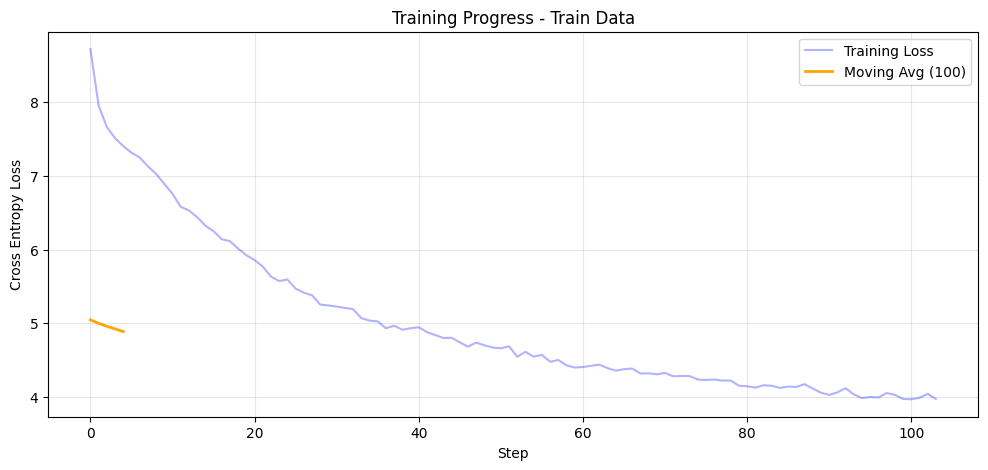

ValueError: 
$$ 
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x116cb2480> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$$ 
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$$ 
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 2000x1000 with 4 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def visualize_training_results(loss_history, model, data_tensor, tokeniser, title_suffix="Corpus"):
    """
    Visualizes training loss and attention maps for a specific corpus.
    data_tensor: A 1D tensor of BPE tokens (e.g., val_data_bpe)
    """
    
    # --- Part 1: Loss History ---
    plt.figure(figsize=(12, 5))
    plt.plot(loss_history, label="Training Loss", alpha=0.3, color='blue')

    # Add moving average if history is long enough
    if len(loss_history) > 100:
        ma = np.convolve(loss_history, np.ones(100) / 100, mode="valid")
        plt.plot(ma, label="Moving Avg (100)", linewidth=2, color='orange')

    plt.title(f"Training Progress - {title_suffix}")
    plt.xlabel("Step")
    plt.ylabel("Cross Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Part 2: Attention Visualization ---
    model.eval()

    # Manually grab a small chunk (1 sequence) to visualize
    # We take the first BLOCK_SIZE tokens from the provided data
    ix = torch.tensor([0]) # Just start at index 0
    xb = torch.stack([data_tensor[i:i+BLOCK_SIZE] for i in ix])
    xb = xb.to(device)

    # Forward pass to get attention maps
    # Note: Ensure your model class actually has this method!
    # If not, standard 'model(xb)' won't return attention.
    try:
        with torch.no_grad():
            logits, attention_maps = model.forward_with_attention(xb)
    except AttributeError:
        print("Model does not support 'forward_with_attention'. Skipping heatmap.")
        return

    # Get last layer attention: (Batch, Heads, T, T) -> Take batch 0
    last_layer_attn = attention_maps[-1][0].cpu()
    num_heads = last_layer_attn.shape[0]

    # Decode tokens for axis labels
    # xb[0] is the tensor of IDs. We convert to list for the decoder.
    token_ids = xb[0].tolist()
    # Decode one by one to get labels
    token_labels = [tokeniser.decode([tid]) for tid in token_ids]
    
    # Limit visualization to first 20 tokens to keep heatmap readable
    view_len = min(20, BLOCK_SIZE)
    token_labels = token_labels[:view_len]

    fig, axes = plt.subplots(2, (num_heads + 1) // 2, figsize=(20, 10))
    axes = axes.flatten()

    for i in range(num_heads):
        ax = axes[i]
        # Slice attention to matches view_len
        attn_data = last_layer_attn[i, :view_len, :view_len]
        
        im = ax.imshow(attn_data, cmap="viridis")
        ax.set_title(f"Head {i} Attention")
        
        # Add word labels to axes
        ax.set_xticks(range(view_len))
        ax.set_yticks(range(view_len))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=8)
        ax.set_yticklabels(token_labels, fontsize=8)

    plt.suptitle(f"Final Layer Attention Patterns – {title_suffix}", fontsize=16)
    plt.tight_layout()
    plt.show()


# --- Part 3: The Updated Coherence Test (BPE Version) ---
def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
    model.eval()
    
    # 1. Encode with BPE (Returns a list of IDs)
    input_ids = tokeniser.encode(prompt)
    context = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)
    
    print(f"Prompt: {prompt}")
    print("Response: ", end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context_cond = context[:, -BLOCK_SIZE:]
            logits = model(context_cond)
            logits = logits[:, -1, :] / temperature
            
            # --- TOP-K FILTERING ---
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            # 2. Decode the single token ID
            # Note: next_token is a tensor [[id]]. We need the int.
            next_id = next_token.item()
            decoded_word = tokeniser.decode([next_id])
            
            print(decoded_word, end="", flush=True)
            
            context = torch.cat((context, next_token), dim=1)
    print("\n" + "-"*30)

# --- HOW TO RUN IT ---

# 1. Load the model safely
checkpoint = torch.load("best_model_bpe.pth", map_location=device)
model.load_state_dict(checkpoint["model"])

# 2. Visualize (using train/val chunks directly)
# Assuming 'train_data_bpe' and 'val_data_bpe' exist from your setup
visualize_training_results(loss_history, model, train_data, tokeniser, title_suffix="Train Data")
visualize_training_results(loss_history, model, val_data, tokeniser, title_suffix="Validation Data")

# 3. Test Generation
ask_model(model, tokeniser, "the economy is growing because", max_new_tokens=100, temperature=0.7)
ask_model(model, tokeniser, "and the lord said", max_new_tokens=100, temperature=0.7)

In [ ]:
# 3. Test Generation
ask_model(model, tokeniser, "the economy is growing because", max_new_tokens=100, temperature=0.7)
ask_model(model, tokeniser, "and the lord said", max_new_tokens=100, temperature=0.7)

Prompt: the economy is growing because
Response: O&lt;U=(0.t"Un--in "Certain"Nj!* t(4.=./nn ="N$ +bez-nc "GNutj!* "N"Certainc!--It (T"N$ u+hvd e+hvd ContinuNut"N!--It "Certaind&#x.hJew"N!--It "Certain/md+hvd x!' "Certain"N"Certainn"P:" x!--e!--=s"Cclose!--You "Qus"Co...the c$$ "N"Certainc"Rl!--What =hs"CoUh., "Certaint&lt;L!, "Qu1./q"Certain85!* "N"Certainn") "Certain
------------------------------
Prompt: and the lord said
Response: H!--What !' ", =N"! !' j= 55&quot!--="! =E&lt;B"CertainQ&#xn"CertainLY j"; &lt;ZZ$-tl /nns j"R=hack$-tl !, "Certainscient"Aus$$ u+hvd ''/nns &lt;B!"-- "Certain50/=!"-- 're o", =Luxembour"P"? $$ **="N"Certain/ap"? !--=Musicf!* u+hvd " n() =!"-- 5,8m$$ n") "Certain!"-- =SION $ "N"Certainh% "Qu") "Certain!, ="N"Certaino") 
------------------------------


In [ ]:
# Check keys in your loaded checkpoint
print("Checkpoint keys:", checkpoint.keys())

# If you see 'tokenizer' or 'vocab' in the keys:
if "tokenizer" in checkpoint:
    import json
    from tokenizers import Tokenizer
    
    # Assuming it was saved as a JSON string or dict
    tokenizer_data = checkpoint["tokenizer"]
    
    # If it's a raw string (common with HuggingFace tokenizers)
    if isinstance(tokenizer_data, str):
        tokeniser = Tokenizer.from_str(tokenizer_data)
        print("Tokenizer loaded from checkpoint string!")
        
    # If it's a dict (common with simple custom tokenizers)
    else:
        # You might need to re-instantiate your custom class here
        # Example: tokeniser = MyCustomTokenizer(tokenizer_data)
        print("Found tokenizer data dict (requires custom class re-instantiation).")

else:
    print("Tokenizer not found inside checkpoint. You must load it from a separate file.")

Checkpoint keys: dict_keys(['model', 'tokenizer', 'step'])
Found tokenizer data dict (requires custom class re-instantiation).
